In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv
import os
load_dotenv()


if os.environ['GEMINI_API_KEY']:
    print('gemini key set')
else:
    print("not set")


gemini key set


# **Initialize LLM**

In [21]:
# Initialize the Gemini model
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0.7,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)

llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain-google-genai': '4.3.4'}}, profile={'name': 'Gemini 3.1 Flash Lite', 'release_date': '2026-05-07', 'last_updated': '2026-05-07', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'minimal'}, google_api_key=SecretStr('**********'), model='gemini-3.1-flash-lite', max_retries=2, client=<google.genai.client.Client object at 0x000001F0F0ECC690>, default_metadata=(), model_kwargs={})

# **Pydantic Schema**

In [ ]:
from pydantic import BaseModel, Field

class graph_schema(BaseModel):
    topic: str = Field(description="The topic of the graph")
    post: str = Field(description="The LinkedIn post content")
    curated_post: str = Field(description="The curated LinkedIn post content")
    
    

## **Create Node Functions**

In [34]:
def create_post(state:graph_schema) -> graph_schema:
    
    # convert the state object to a dictionary
    state = state.model_dump()
    topic = state["topic"]
    # post = state.get("post")
    # curated_post = state.get("curated_post")
    
    
    post = llm.invoke(f"Create a LinkedIn post about {topic}.").content[0]["text"]
    
    state['post'] = post
    
    return state


def curate_post(state:graph_schema) -> graph_schema:
    
    # convert the state object to a dictionary
    state = state.model_dump()
    # topic = state.get("topic")
    post = state["post"]
    
    curated_post = llm.invoke(f"Curate the following LinkedIn post: {post}. Use a GenZ tone.").content[0]["text"]
    
    state['curated_post'] = curated_post
    
    return state

## **Create State Graph**

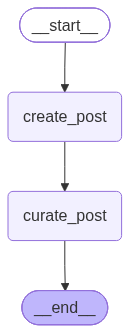

In [35]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)



pydantic_graph = graph.compile()

Image(pydantic_graph.get_graph().draw_mermaid_png())

In [36]:
pydantic_graph.invoke(
    {
        "topic": "The future of AI in healthcare",
        "post": "",
        "curated_post": ""
    }
)

{'topic': 'The future of AI in healthcare',
 'post': 'Here are three options for your LinkedIn post, depending on the tone you want to strike:\n\n### Option 1: The "Visionary/Thought Leader" approach (Best for engagement)\n\n**Headline: AI in healthcare isn’t about replacing doctors. It’s about giving them their humanity back.**\n\nFor years, we’ve talked about AI as a distant "future" for medicine. But the future is already here—and it’s quieter, faster, and more precise than we ever imagined.\n\nWe are moving past the hype phase and into the era of **precision healthcare.** Here is where the real shift is happening:\n\n🔹 **Hyper-personalized treatment:** Moving from "one-size-fits-all" to DNA-driven, patient-specific care.\n🔹 **Administrative relief:** AI is finally tackling the burnout crisis by automating clinical documentation, allowing providers to spend more time looking at patients and less time staring at screens.\n🔹 **Predictive diagnostics:** Catching diseases like oncology 